# 03 — Dataset Preparation V2
## Eye Disease Detection System

Purpose: inspect all available eye-image datasets, validate images, identify class mappings, detect exact duplicates/corrupt files, and prepare a clean combined dataset for the next EfficientNetV2-B0 training stage.

Important: this notebook does NOT train the model and does NOT modify/delete original datasets.

Current target: 5 classes (Class 0–Class 4).


In [10]:
# STEP 1 — Imports and configuration

from pathlib import Path
import json
import hashlib
import shutil

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

SEED = 42
TARGET_CLASSES = [0, 1, 2, 3, 4]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR

DATASET_DIR = PROJECT_DIR / "dataset"
PREPROCESSING_DIR = PROJECT_DIR / "preprocessing"
REPORT_DIR = PROJECT_DIR / "reports" / "dataset"
PROCESSED_DIR = PREPROCESSING_DIR / "processed_dataset_v2"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATASET_DIR)
print("Processed dataset :", PROCESSED_DIR)
print("Target classes    :", TARGET_CLASSES)


Project directory : d:\Practice Projects\Disease Detection
Dataset directory : d:\Practice Projects\Disease Detection\dataset
Processed dataset : d:\Practice Projects\Disease Detection\preprocessing\processed_dataset_v2
Target classes    : [0, 1, 2, 3, 4]


In [11]:
# STEP 2 — Verify paths

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATASET_DIR}\n"
        "Update DATASET_DIR in Step 1 to the actual dataset folder."
    )

print("Dataset directory exists:", DATASET_DIR.exists())
for p in sorted(DATASET_DIR.iterdir()):
    if p.is_dir():
        print(" -", p.name)


Dataset directory exists: True
 - Dataset
 - Eye Disease detection
 - GlaucomaFundusImaging
 - Messidor-2+EyePac_Balanced


In [12]:
# STEP 3 — Discover datasets and images

def is_image_file(path):
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS

all_image_paths = [p for p in DATASET_DIR.rglob("*") if is_image_file(p)]
print("Total image files discovered:", len(all_image_paths))

dataset_roots = [p for p in DATASET_DIR.iterdir() if p.is_dir()]

dataset_records = []
for root in sorted(dataset_roots):
    count = sum(1 for p in root.rglob("*") if is_image_file(p))
    dataset_records.append({
        "dataset_name": root.name,
        "dataset_path": str(root),
        "image_count": count
    })

dataset_df = pd.DataFrame(dataset_records).sort_values(
    "image_count", ascending=False
).reset_index(drop=True)

display(dataset_df)
dataset_df.to_csv(REPORT_DIR / "dataset_inventory.csv", index=False)


Total image files discovered: 27880


,dataset_name,dataset_path,image_count
0,GlaucomaFundusImaging,d:\Practice Projects\Disease Detection\dataset...,19884
1,Eye Disease detection,d:\Practice Projects\Disease Detection\dataset...,4217
2,Dataset,d:\Practice Projects\Disease Detection\dataset...,1979
3,Messidor-2+EyePac_Balanced,d:\Practice Projects\Disease Detection\dataset...,1800


In [13]:
# STEP 4 — Inspect class folders for every dataset

def detect_class_folders(dataset_root):
    rows = []
    for child in sorted(dataset_root.iterdir()):
        if child.is_dir():
            image_count = sum(1 for p in child.rglob("*") if is_image_file(p))
            if image_count > 0:
                rows.append({
                    "dataset_name": dataset_root.name,
                    "dataset_class": child.name,
                    "image_count": image_count,
                    "class_path": str(child)
                })
    return rows

class_folder_records = []
for root in dataset_roots:
    class_folder_records.extend(detect_class_folders(root))

class_folder_df = pd.DataFrame(class_folder_records)

if len(class_folder_df):
    display(class_folder_df)
    class_folder_df.to_csv(REPORT_DIR / "dataset_class_distribution.csv", index=False)
else:
    print("No immediate class-folder structure detected.")
    print("A metadata/CSV label file may be required for datasets without class folders.")


,dataset_name,dataset_class,image_count,class_path
0,Dataset,test,198,d:\Practice Projects\Disease Detection\dataset...
1,Dataset,train,1385,d:\Practice Projects\Disease Detection\dataset...
2,Dataset,val,396,d:\Practice Projects\Disease Detection\dataset...
3,Eye Disease detection,cataract,1038,d:\Practice Projects\Disease Detection\dataset...
4,Eye Disease detection,diabetic_retinopathy,1098,d:\Practice Projects\Disease Detection\dataset...
5,Eye Disease detection,glaucoma,1007,d:\Practice Projects\Disease Detection\dataset...
6,Eye Disease detection,normal,1074,d:\Practice Projects\Disease Detection\dataset...
7,GlaucomaFundusImaging,G1020,7180,d:\Practice Projects\Disease Detection\dataset...
8,GlaucomaFundusImaging,ORIGA,3904,d:\Practice Projects\Disease Detection\dataset...
9,GlaucomaFundusImaging,REFUGE,8800,d:\Practice Projects\Disease Detection\dataset...


## STEP 5 — Class mapping

The current project uses Class 0–Class 4.

Do not assume that identical folder names across different datasets represent identical medical labels.

Only verified mappings should be added below. The current established balanced dataset is mapped using its existing Class 0–Class 4 folder structure.


In [14]:
# STEP 6 — Configure VERIFIED source-label mappings

# Add only mappings verified from the source dataset documentation.
# Format:
# EXPLICIT_DATASET_MAPPINGS["DatasetName"] = {
#     "source_label": target_class
# }

EXPLICIT_DATASET_MAPPINGS = {
    "Messidor-2+EyePac_Balanced": {
        "0": 0,
        "1": 1,
        "2": 2,
        "3": 3,
        "4": 4,
    }
}

print(json.dumps(EXPLICIT_DATASET_MAPPINGS, indent=2))


{
  "Messidor-2+EyePac_Balanced": {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4
  }
}


In [15]:
# STEP 7 — Build image inventory and mapping status

def infer_source_label(image_path, dataset_root):
    relative = image_path.relative_to(dataset_root)
    parts = relative.parts
    return parts[0] if len(parts) >= 2 else None

inventory = []

for dataset_root in dataset_roots:
    mapping = EXPLICIT_DATASET_MAPPINGS.get(dataset_root.name, {})
    dataset_images = [p for p in dataset_root.rglob("*") if is_image_file(p)]

    for image_path in dataset_images:
        source_label = infer_source_label(image_path, dataset_root)
        target_class = mapping.get(str(source_label))
        status = "MAPPED" if target_class in TARGET_CLASSES else "UNMAPPED"

        inventory.append({
            "dataset_name": dataset_root.name,
            "dataset_path": str(dataset_root),
            "image_path": str(image_path),
            "source_label": str(source_label) if source_label is not None else None,
            "target_class": target_class,
            "mapping_status": status
        })

inventory_df = pd.DataFrame(inventory)

print("Total inventory records:", len(inventory_df))
if len(inventory_df):
    display(
        inventory_df.groupby(["dataset_name", "mapping_status"], dropna=False)
        .size().reset_index(name="count")
    )

inventory_df.to_csv(REPORT_DIR / "image_inventory_mapping.csv", index=False)


Total inventory records: 27880


,dataset_name,mapping_status,count
0,Dataset,UNMAPPED,1979
1,Eye Disease detection,UNMAPPED,4217
2,GlaucomaFundusImaging,UNMAPPED,19884
3,Messidor-2+EyePac_Balanced,MAPPED,1800


In [16]:
# STEP 8 — Safe mapping gate

unmapped_df = inventory_df[inventory_df["mapping_status"] != "MAPPED"].copy()

if len(unmapped_df):
    print("DATASET PREPARATION BLOCKED — REVIEW REQUIRED")
    print("Unmapped image count:", len(unmapped_df))
    display(
        unmapped_df.groupby(["dataset_name", "source_label"], dropna=False)
        .size().reset_index(name="count")
    )
    print("Add ONLY verified mappings in Step 6, then rerun from Step 7.")
else:
    print("All discovered images have a verified target-class mapping.")


DATASET PREPARATION BLOCKED — REVIEW REQUIRED
Unmapped image count: 26080


,dataset_name,source_label,count
0,Dataset,test,198
1,Dataset,train,1385
2,Dataset,val,396
3,Eye Disease detection,cataract,1038
4,Eye Disease detection,diabetic_retinopathy,1098
5,Eye Disease detection,glaucoma,1007
6,Eye Disease detection,normal,1074
7,GlaucomaFundusImaging,G1020,7180
8,GlaucomaFundusImaging,ORIGA,3904
9,GlaucomaFundusImaging,REFUGE,8800


Add ONLY verified mappings in Step 6, then rerun from Step 7.


In [17]:
# STEP 9 — Validate images

validation_records = []

for row in inventory_df.itertuples(index=False):
    path = Path(row.image_path)
    record = {
        "image_path": row.image_path,
        "dataset_name": row.dataset_name,
        "source_label": row.source_label,
        "target_class": row.target_class,
        "mapping_status": row.mapping_status,
        "readable": False,
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
        "validation_status": "INVALID"
    }

    if row.mapping_status != "MAPPED":
        validation_records.append(record)
        continue

    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            record["width"], record["height"] = img.size
            record["mode"] = img.mode
            record["format"] = img.format
        record["readable"] = True
        record["validation_status"] = "VALID"
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        record["validation_status"] = f"INVALID: {type(exc).__name__}"

    validation_records.append(record)

validation_df = pd.DataFrame(validation_records)

display(validation_df["validation_status"].value_counts(dropna=False))
validation_df.to_csv(REPORT_DIR / "image_validation_report.csv", index=False)

print("Valid images:", int((validation_df["validation_status"] == "VALID").sum()))
print("Invalid images:", int((validation_df["validation_status"] != "VALID").sum()))


validation_status
INVALID    26080
VALID       1800
Name: count, dtype: int64

Valid images: 1800
Invalid images: 26080


In [18]:
# STEP 10 — Exact duplicate detection using SHA-256

def file_sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

valid_paths = validation_df.loc[
    validation_df["validation_status"] == "VALID", "image_path"
].tolist()

hash_records = []
for path_str in valid_paths:
    try:
        hash_records.append({
            "image_path": path_str,
            "sha256": file_sha256(Path(path_str))
        })
    except OSError:
        pass

hash_df = pd.DataFrame(hash_records)

if len(hash_df):
    duplicate_groups = (
        hash_df.groupby("sha256")
        .filter(lambda x: len(x) > 1)
        .sort_values("sha256")
    )
else:
    duplicate_groups = pd.DataFrame()

print("Valid files hashed:", len(hash_df))
print("Duplicate image files:", len(duplicate_groups))

if len(duplicate_groups):
    display(duplicate_groups.head(50))

hash_df.to_csv(REPORT_DIR / "image_hashes.csv", index=False)
duplicate_groups.to_csv(REPORT_DIR / "duplicate_images.csv", index=False)


Valid files hashed: 1800
Duplicate image files: 469


,image_path,sha256
1644,d:\Practice Projects\Disease Detection\dataset...,0009c1de84798a21cbc7e74596e3553b34172c395a2f46...
1643,d:\Practice Projects\Disease Detection\dataset...,0009c1de84798a21cbc7e74596e3553b34172c395a2f46...
1571,d:\Practice Projects\Disease Detection\dataset...,02283aeaa909453864b4958879d58721a212e1534f304a...
1572,d:\Practice Projects\Disease Detection\dataset...,02283aeaa909453864b4958879d58721a212e1534f304a...
1501,d:\Practice Projects\Disease Detection\dataset...,0270137bc909a0541b9fe791cc9c403d8a003006203986...
1500,d:\Practice Projects\Disease Detection\dataset...,0270137bc909a0541b9fe791cc9c403d8a003006203986...
483,d:\Practice Projects\Disease Detection\dataset...,03f2ae44d51f257432efcb99bda268e44af27c1fca7f73...
482,d:\Practice Projects\Disease Detection\dataset...,03f2ae44d51f257432efcb99bda268e44af27c1fca7f73...
392,d:\Practice Projects\Disease Detection\dataset...,048a4e8b18566ff01245f796f0d6d689ee511a60b4a1f1...
393,d:\Practice Projects\Disease Detection\dataset...,048a4e8b18566ff01245f796f0d6d689ee511a60b4a1f1...


In [19]:
# STEP 11 — Create clean unique inventory

valid_df = validation_df[validation_df["validation_status"] == "VALID"].copy()

hash_map = dict(zip(hash_df["image_path"], hash_df["sha256"]))
valid_df["sha256"] = valid_df["image_path"].map(hash_map)

clean_df = (
    valid_df.sort_values(["sha256", "image_path"])
    .drop_duplicates(subset=["sha256"], keep="first")
    .reset_index(drop=True)
)

clean_df["target_class"] = clean_df["target_class"].astype(int)

print("Valid images before duplicate removal:", len(valid_df))
print("Unique usable images:", len(clean_df))
print("Removed exact duplicates:", len(valid_df) - len(clean_df))

display(
    clean_df["target_class"].value_counts()
    .reindex(TARGET_CLASSES, fill_value=0)
    .rename_axis("target_class").reset_index(name="count")
)

clean_df.to_csv(REPORT_DIR / "clean_unique_image_inventory.csv", index=False)


Valid images before duplicate removal: 1800
Unique usable images: 1564
Removed exact duplicates: 236


,target_class,count
0,0,360
1,1,268
2,2,345
3,3,359
4,4,232


In [20]:
# STEP 12 — Verify all five target classes

class_counts = clean_df["target_class"].value_counts().reindex(
    TARGET_CLASSES, fill_value=0
)

display(class_counts.rename_axis("target_class").reset_index(name="count"))

missing_classes = [c for c in TARGET_CLASSES if class_counts[c] == 0]

if missing_classes:
    print("DATASET PREPARATION BLOCKED — REVIEW REQUIRED")
    print("Missing target classes:", missing_classes)
else:
    print("All five target classes contain valid images.")


,target_class,count
0,0,360
1,1,268
2,2,345
3,3,359
4,4,232


All five target classes contain valid images.


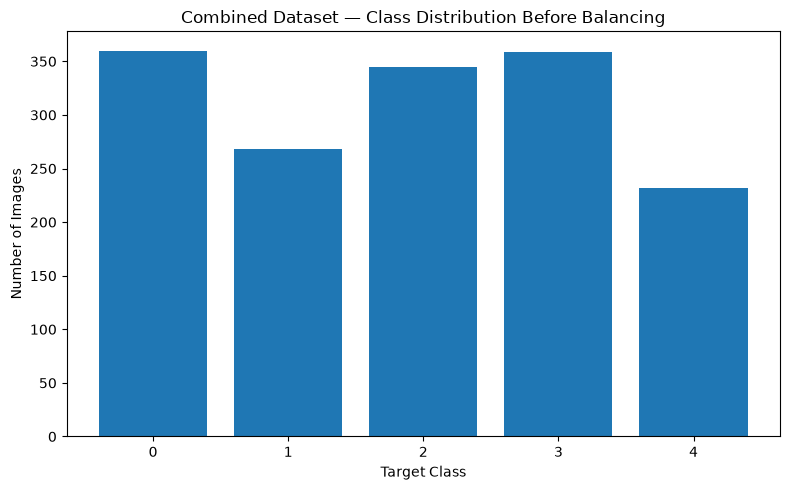

In [21]:
# STEP 13 — Plot class distribution before balancing

plt.figure(figsize=(8, 5))
plt.bar([str(c) for c in TARGET_CLASSES], [class_counts[c] for c in TARGET_CLASSES])
plt.xlabel("Target Class")
plt.ylabel("Number of Images")
plt.title("Combined Dataset — Class Distribution Before Balancing")
plt.tight_layout()
plt.savefig(
    REPORT_DIR / "combined_class_distribution_before_balancing.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [22]:
# STEP 14 — Source dataset contribution

source_class_df = (
    clean_df.groupby(["dataset_name", "target_class"])
    .size().reset_index(name="count")
)

display(source_class_df)

source_class_pivot = source_class_df.pivot_table(
    index="dataset_name",
    columns="target_class",
    values="count",
    fill_value=0
)

display(source_class_pivot)

source_class_df.to_csv(
    REPORT_DIR / "source_dataset_class_contribution.csv",
    index=False
)


,dataset_name,target_class,count
0,Messidor-2+EyePac_Balanced,0,360
1,Messidor-2+EyePac_Balanced,1,268
2,Messidor-2+EyePac_Balanced,2,345
3,Messidor-2+EyePac_Balanced,3,359
4,Messidor-2+EyePac_Balanced,4,232


target_class,0,1,2,3,4
dataset_name,,,,,
Messidor-2+EyePac_Balanced,360.0,268.0,345.0,359.0,232.0


In [23]:
# STEP 15 — Balance the combined dataset

# Conservative strategy: downsample each class to the smallest class.
# No synthetic images are created.
# Original datasets are untouched.

rng = np.random.default_rng(SEED)
min_class_count = int(class_counts.min())

balanced_parts = []

for class_id in TARGET_CLASSES:
    class_df = clean_df[clean_df["target_class"] == class_id].copy()

    if len(class_df) > min_class_count:
        selected = rng.choice(len(class_df), size=min_class_count, replace=False)
        class_df = class_df.iloc[selected].copy()

    balanced_parts.append(class_df)

balanced_df = (
    pd.concat(balanced_parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

balanced_counts = balanced_df["target_class"].value_counts().reindex(
    TARGET_CLASSES, fill_value=0
)

print("Balanced dataset size:", len(balanced_df))
display(balanced_counts.rename_axis("target_class").reset_index(name="count"))


Balanced dataset size: 1160


,target_class,count
0,0,232
1,1,232
2,2,232
3,3,232
4,4,232


In [24]:
# STEP 16 — Stratified 70/15/15 split

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["target_class"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["target_class"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

final_metadata_df = pd.concat(
    [train_df, val_df, test_df], ignore_index=True
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(final_metadata_df))


Train: 812
Validation: 174
Test: 174
Total: 1160


In [25]:
# STEP 17 — Verify split distributions

split_distribution = (
    final_metadata_df.groupby(["split", "target_class"])
    .size().unstack(fill_value=0)
    .reindex(columns=TARGET_CLASSES, fill_value=0)
)

display(split_distribution)
split_distribution.to_csv(REPORT_DIR / "final_split_class_distribution.csv")

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    counts = split_df["target_class"].value_counts().reindex(
        TARGET_CLASSES, fill_value=0
    )
    print(split_name, ":", counts.to_dict())


target_class,0,1,2,3,4
split,,,,,
test,35,35,35,35,34
train,162,163,162,162,163
validation,35,34,35,35,35


train : {0: 162, 1: 163, 2: 162, 3: 162, 4: 163}
validation : {0: 35, 1: 34, 2: 35, 3: 35, 4: 35}
test : {0: 35, 1: 35, 2: 35, 3: 35, 4: 34}


In [26]:
# STEP 18 — Copy images into final processed dataset

for class_id in TARGET_CLASSES:
    (PROCESSED_DIR / f"Class {class_id}").mkdir(parents=True, exist_ok=True)

def destination_for(class_dir, original_path, dataset_name):
    source = Path(original_path)
    dest = class_dir / f"{source.stem}{source.suffix.lower()}"

    if dest.exists():
        safe_dataset = "".join(
            ch if ch.isalnum() else "_" for ch in dataset_name
        )[:40]
        dest = class_dir / f"{safe_dataset}__{source.name}"

    return dest

copy_records = []

for row in final_metadata_df.itertuples(index=False):
    source = Path(row.image_path)
    class_dir = PROCESSED_DIR / f"Class {int(row.target_class)}"
    destination = destination_for(class_dir, source, row.dataset_name)

    if not destination.exists():
        shutil.copy2(source, destination)

    copy_records.append({
        "source_path": str(source),
        "processed_path": str(destination),
        "dataset_name": row.dataset_name,
        "source_label": row.source_label,
        "target_class": int(row.target_class),
        "split": row.split,
        "sha256": row.sha256
    })

processed_metadata_df = pd.DataFrame(copy_records)

processed_metadata_df.to_csv(
    PREPROCESSING_DIR / "splits_v2_metadata.csv", index=False
)

print("Processed dataset:", PROCESSED_DIR)
print("Processed images:", len(processed_metadata_df))


Processed dataset: d:\Practice Projects\Disease Detection\preprocessing\processed_dataset_v2
Processed images: 1160


In [27]:
# STEP 19 — Save train/validation/test CSV files

for split_name in ["train", "validation", "test"]:
    processed_metadata_df[
        processed_metadata_df["split"] == split_name
    ].to_csv(
        PREPROCESSING_DIR / f"{split_name}_v2.csv",
        index=False
    )

print("Saved:")
print(PREPROCESSING_DIR / "train_v2.csv")
print(PREPROCESSING_DIR / "validation_v2.csv")
print(PREPROCESSING_DIR / "test_v2.csv")
print(PREPROCESSING_DIR / "splits_v2_metadata.csv")


Saved:
d:\Practice Projects\Disease Detection\preprocessing\train_v2.csv
d:\Practice Projects\Disease Detection\preprocessing\validation_v2.csv
d:\Practice Projects\Disease Detection\preprocessing\test_v2.csv
d:\Practice Projects\Disease Detection\preprocessing\splits_v2_metadata.csv


In [28]:
# STEP 20 — Final integrity checks

required_columns = {
    "source_path", "processed_path", "dataset_name",
    "source_label", "target_class", "split", "sha256"
}

missing_columns = required_columns - set(processed_metadata_df.columns)
if missing_columns:
    raise RuntimeError(f"Missing metadata columns: {missing_columns}")

if not set(processed_metadata_df["target_class"]).issubset(set(TARGET_CLASSES)):
    raise RuntimeError("Invalid target class detected.")

if set(processed_metadata_df["split"]) != {"train", "validation", "test"}:
    raise RuntimeError("Unexpected split labels detected.")

hash_split_counts = processed_metadata_df.groupby("sha256")["split"].nunique()
leakage_hashes = hash_split_counts[hash_split_counts > 1]

print("Duplicate/hash leakage across splits:", len(leakage_hashes))

if len(leakage_hashes):
    raise RuntimeError("Data leakage detected across train/validation/test.")

missing_processed = [
    p for p in processed_metadata_df["processed_path"]
    if not Path(p).exists()
]

print("Missing processed files:", len(missing_processed))

if missing_processed:
    raise RuntimeError("Some processed image files are missing.")

print("All integrity checks passed.")


Duplicate/hash leakage across splits: 0
Missing processed files: 0
All integrity checks passed.


In [29]:
# STEP 21 — Final summary report

final_class_distribution = (
    processed_metadata_df.groupby(["split", "target_class"])
    .size().unstack(fill_value=0)
    .reindex(columns=TARGET_CLASSES, fill_value=0)
)

summary = {
    "project_directory": str(PROJECT_DIR),
    "source_dataset_directory": str(DATASET_DIR),
    "processed_dataset_directory": str(PROCESSED_DIR),
    "total_images": int(len(processed_metadata_df)),
    "train_images": int((processed_metadata_df["split"] == "train").sum()),
    "validation_images": int((processed_metadata_df["split"] == "validation").sum()),
    "test_images": int((processed_metadata_df["split"] == "test").sum()),
    "target_classes": TARGET_CLASSES,
    "datasets_included": sorted(
        processed_metadata_df["dataset_name"].unique().tolist()
    )
}

with open(
    REPORT_DIR / "dataset_preparation_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary, f, indent=2)

display(pd.DataFrame([
    {
        "split": split,
        **{
            f"Class {c}": int(final_class_distribution.loc[split, c])
            for c in TARGET_CLASSES
        },
        "Total": int(final_class_distribution.loc[split].sum())
    }
    for split in final_class_distribution.index
]))

print("Datasets included:")
for name in summary["datasets_included"]:
    print(" -", name)

print("Processed dataset:", PROCESSED_DIR)
print("Metadata CSV:", PREPROCESSING_DIR / "splits_v2_metadata.csv")
print("Summary JSON:", REPORT_DIR / "dataset_preparation_summary.json")


,split,Class 0,Class 1,Class 2,Class 3,Class 4,Total
0,test,35,35,35,35,34,174
1,train,162,163,162,162,163,812
2,validation,35,34,35,35,35,174


Datasets included:
 - Messidor-2+EyePac_Balanced
Processed dataset: d:\Practice Projects\Disease Detection\preprocessing\processed_dataset_v2
Metadata CSV: d:\Practice Projects\Disease Detection\preprocessing\splits_v2_metadata.csv
Summary JSON: d:\Practice Projects\Disease Detection\reports\dataset\dataset_preparation_summary.json


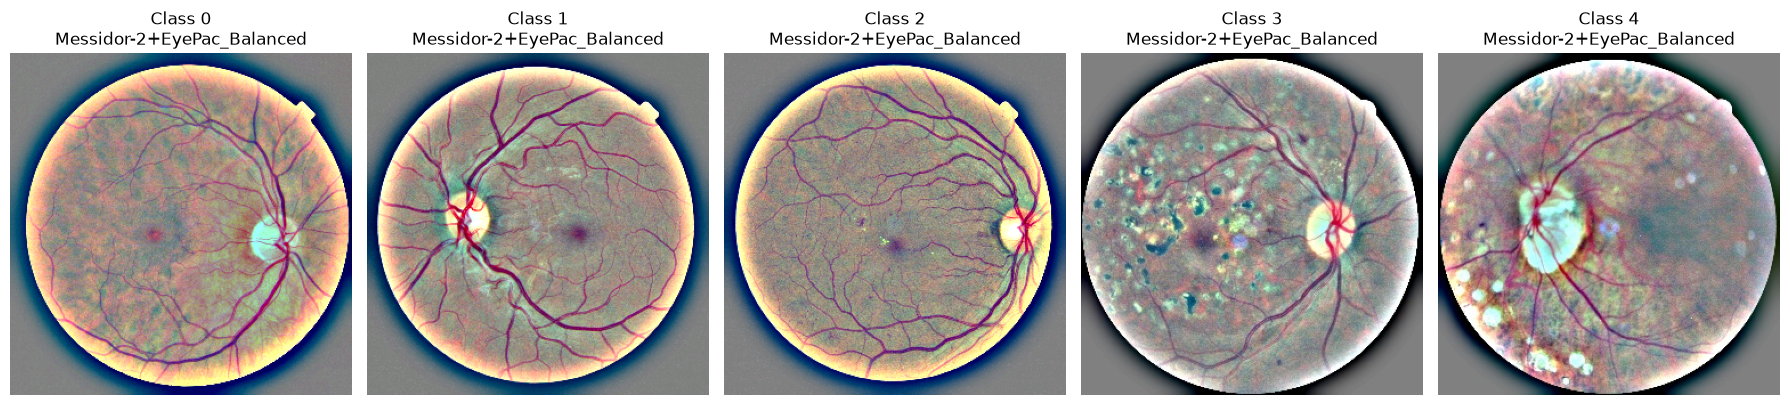

In [30]:
# STEP 22 — Representative samples from all classes

sample_rows = []

for class_id in TARGET_CLASSES:
    candidates = processed_metadata_df[
        processed_metadata_df["target_class"] == class_id
    ]
    if len(candidates):
        sample_rows.append(
            candidates.sample(
                n=1, random_state=SEED + class_id
            ).iloc[0]
        )

fig, axes = plt.subplots(1, len(sample_rows), figsize=(18, 4))
if len(sample_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, sample_rows):
    with Image.open(Path(row["processed_path"])) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(f"Class {row['target_class']}\n{row['dataset_name']}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    REPORT_DIR / "representative_samples_all_classes.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [31]:
# STEP 23 — Final readiness gate

problems = []

for class_id in TARGET_CLASSES:
    count = int((processed_metadata_df["target_class"] == class_id).sum())
    if count == 0:
        problems.append(f"Class {class_id} has zero images.")

for split_name in ["train", "validation", "test"]:
    if (processed_metadata_df["split"] == split_name).sum() == 0:
        problems.append(f"{split_name} split is empty.")

if len(leakage_hashes):
    problems.append("Duplicate/hash leakage exists between splits.")

if missing_processed:
    problems.append("Some processed image files are missing.")

invalid_classes = set(processed_metadata_df["target_class"]) - set(TARGET_CLASSES)
if invalid_classes:
    problems.append(f"Invalid target classes: {invalid_classes}")

if problems:
    print("DATASET PREPARATION BLOCKED — REVIEW REQUIRED")
    for problem in problems:
        print("-", problem)
else:
    print("DATASET PREPARATION READY FOR TRAINING")
    print()
    print("The processed dataset is ready for the next EfficientNetV2-B0 training stage.")
    print("Do not train until every newly added dataset's medical label mapping is verified.")


DATASET PREPARATION READY FOR TRAINING

The processed dataset is ready for the next EfficientNetV2-B0 training stage.
Do not train until every newly added dataset's medical label mapping is verified.
